## Hausaufgabe 2
### Kerosintank in einer Flugzeugtragfläche


 .<div style="width:50%; margin: 0 auto;">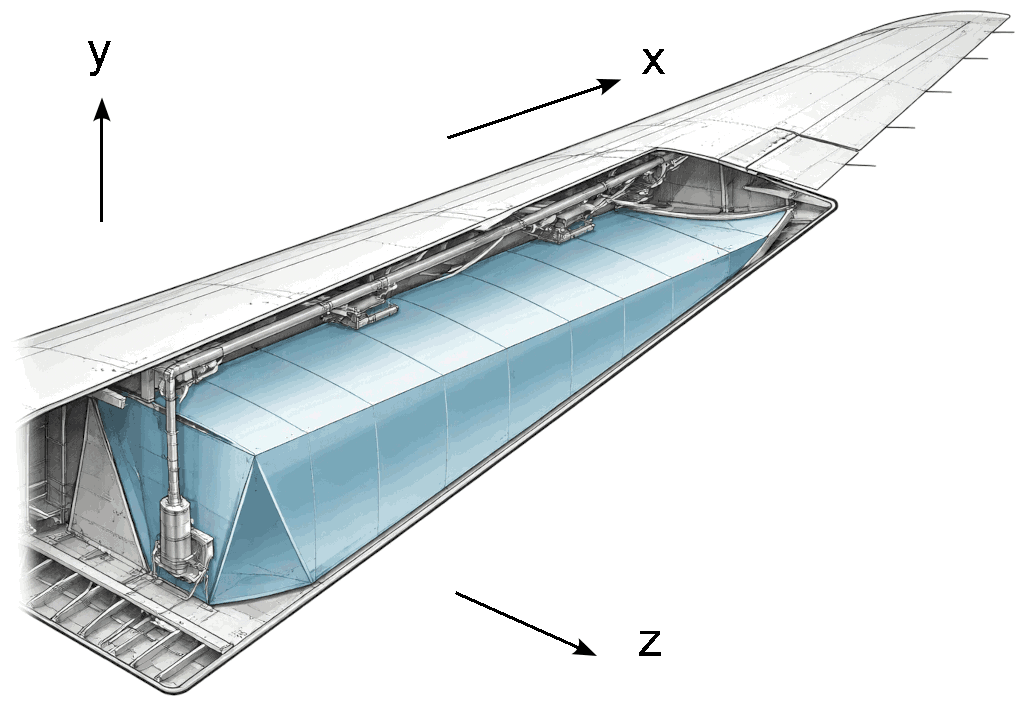</div>
 In einer Flugzeugtragfläche befindet sich ein Kerosintank, der zu Wartungszwecken entleert werden soll. Dafür befindet sich an der tiefsten Stelle ein Ablassventil, durch das der Tank entleert werden kann. Dabei fließt das Kerosin durch die Wirkung der Schwerkraft aus dem Tank heraus. Zur Planung der Wartungsarbeiten soll die Zeit berechnet werden, die benötigt wird, um den Tank vollständig zu entleeren.
 
 Die Form des Tanks kann vereinfacht durch einen _gekippten_ Pyramidenstumpf beschrieben werden. In einem weiter vereinfachten Fall ist die senkrechte Grundfläche bei $x=0$ an der Wurzel der Tragfläche und die senkrechte Deckfläche bei $x=L$ in Richtung der Spitze der Tragfläche. Die (obere) Deckfläche des Tanks ist eine waagerechte Ebene bei $y=H$, die untere Grundfläche ist eine schräge Ebene und wird durch die Funktion $y(x)=\frac{2H}{3L}x$ beschrieben. Vorn und hinten ist der Tank durch die senkrechten Ebenen $z=0$ und $z=W$ begrenzt.

 .<div style="width:50%; margin: 0 auto;">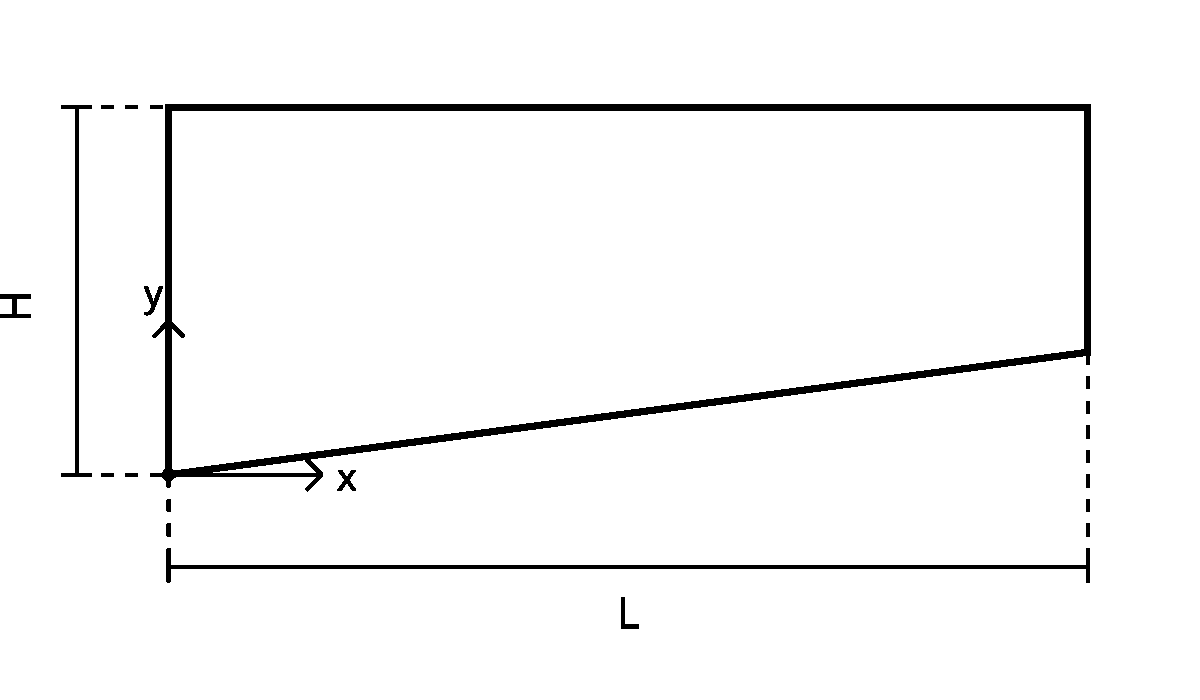</div>

Schreiben Sie als ersten Schritt zur Lösung eine Funktion `oberflaeche(h, L, H, W)`, die die Oberfläche der Flüssigkeit in Abhängigkeit von der Füllhöhe $h$ berechnet. Für $h\leq 0$ ist der Tank leer und für $h\geq H$ ist der Tank voll. Testen Sie die Funktion für die Werte $L=10$ m, $H=2$ m und $W=3$ m. Berechnen Sie die Oberfläche für die Füllhöhen $h=0.5$ m, $h=1$ m, $h=1.5$ und $h=2$ m und geben Sie die Ergebnisse aus!

Lösungshinweis 1: Bei niedrigerer Füllhöhe berührt der Kerosinspiegel die schräge untere Grundfläche. Ab einer gewissen Füllhöhe berührt er statt dessen die senkrechte Endfläche bei $x=L$.

In [35]:
# Hier eigenen Code schreiben:
def oberflaeche(h, L, H, W):
    y_x = 2*H/(3*L)*L
    if h <= 0:
        print('tank ist lehr oberfläche is 0')
        A = 0
    elif h >= H: 
        A = W*L
        print('tank ist voll')
    else:
        if h >= y_x:
            A = W*L
        else:
            A = W*(h*3*L/(2*H))
    return A

h_list = [0.5, 1, 1.5, 2]
L = 10
H = 2
W = 3

for i in h_list:
    A = oberflaeche(i,L,H,W)
    print(A)

11.25
22.5
30
tank ist voll
30


In [36]:
# Diese Zelle kann ausgeführt werden, um die Plausibilität der Ergebnisse zu überprüfen.
# nur bei Fehlern werden Fehlermeldungen ausgegeben
assert oberflaeche(0, 10, 2, 3) == 0, "Test für leeren Tank fehlgeschlagen"
assert oberflaeche(2, 10, 2, 3) == 30, "Test für vollen Tank fehlgeschlagen"
assert oberflaeche(0.5, 10, 2, 3) < oberflaeche(1, 10, 2, 3) < oberflaeche(1.5, 10, 2, 3), "Test für steigende Oberfläche fehlgeschlagen"
assert oberflaeche(-1, 10, 2, 3) == 0, "Test für h=-1 m fehlgeschlagen"
assert oberflaeche(3, 10, 2, 3) == 30, "Test für h=3 m fehlgeschlagen"

tank ist lehr oberfläche is 0
tank ist voll
tank ist lehr oberfläche is 0
tank ist voll


Schreiben Sie nun eine Funktion `volumen(h, L, H, W)`, die das Volumen der Flüssigkeit im Tank in Abhängigkeit von der Füllhöhe $h$ berechnet. Testen Sie die Funktion für die gleichen Werte wie zuvor. Das Volumen kann durch Integration der Oberfläche über die Füllhöhe berechnet werden. Diese Integration soll numerisch durchgeführt werden, indem das Volumen näherungsweise als Summe von dünnen waagerechten Scheiben, die aufeinander gestapelt sind, berechnet wird. Die Scheiben haben jeweils die Oberfläche der Flüssigkeit als Querschnittsfläche und die Höhe $\Delta h$. 

Lösungshinweis 2: verwenden Sie eine Schleife, um die Summe zu berechnen, und wählen Sie eine geeignete Schrittweite $\Delta h$ für die Füllhöhe.

In [37]:
# Hier eigenen Code schreiben:
def volumen(h,L,H,W):
    dy = 0.1
    V = 0
    n_y = [i * dy + dy/2 for i in range(int(h/dy))]
    for i in n_y:
        if i > 0:
            dV = dy * oberflaeche(i,L,H,W)
            V += dV
    return V

for i in h_list:
    V   = volumen(i, L, H, W)
    print(V)

2.8125
11.25
25.012500000000003
40.0125


In [38]:
# Diese Zelle kann ausgeführt werden, um die Plausibilität der Ergebnisse zu überprüfen.
# nur bei Fehlern werden Fehlermeldungen ausgegeben
assert volumen(0, 10, 2, 3) == 0, "Test für leeren Tank fehlgeschlagen"
assert volumen(2, 10, 2, 3) > 40, "Test für vollen Tank fehlgeschlagen"
assert volumen(0.5, 10, 2, 3) < volumen(1, 10, 2, 3) < volumen(1.5, 10, 2, 3), "Test für steigendes Volumen fehlgeschlagen"


Die Funktion `volumen(h, L, H, W)` kann nun verwendet werden, um die Zeit zu berechnen, die benötigt wird, um den Tank vollständig zu entleeren. Dazu muss zunächst die Geschwindigkeit des Kerosinflusses durch das Ablassventil berechnet werden. Diese Geschwindigkeit kann mithilfe der Toricelli-Formel berechnet werden, die besagt, dass die Geschwindigkeit $v$ des ausströmenden Kerosins durch die Gleichung $v=\sqrt{2gh}$ gegeben ist, wobei $g$ die Erdbeschleunigung ist. Mit dem Querschnitt $A$ des Ventils bei vollständiger Öffnung kann berechnet werden, wie viel Volumen pro Zeiteinheit durch das Ablassventil austritt. Damit ist es auch möglich, zu berechnen, wie lange es bei einer bestimmten Füllhöhe dauert, bis eine kleine Menge Volumen $\Delta V$ durch das Ablassventil ausgetreten ist. Schreiben Sie eine Funktion `zeitprovolumen(h, L, H, W, A, delta_V)`, die diese Zeit ausrechnet. Testen Sie die Funktion mit einem Querschnitt von $A=0.01$ m² und einer kleinen Volumeneinheit von $\Delta V=0.1$ m³ für die gleichen Werte wie zuvor. Berechnen Sie das Ergebnis für die Füllhöhen $h=0.5$ m, $h=1$ m und $h=1.5$ m und geben Sie es aus.


In [39]:
# Hier eigenen Code schreiben
delta_V = 0.1
Austrits_querschnitt = 0.01


def zeitprovolumen(h, L, H, W, A, delta_V):
    G = 9.81 #m/s^2
    v = (2*G*h)**0.5 #m/s
    V_dot = v * A # m^3/s
    dt  = delta_V/V_dot
    return dt





In [40]:
# Diese Zelle kann ausgeführt werden, um die Plausibilität der Ergebnisse zu überprüfen.
# nur bei Fehlern werden Fehlermeldungen ausgegeben
assert zeitprovolumen(0.5, 10, 2, 3, 0.01, 0.1) > zeitprovolumen(1.5, 10, 2, 3, 0.01, 0.1), "Test für steigende Zeit fehlgeschlagen"


Berechnen Sie schließlich die Zeit, die benötigt wird, um den Tank vollständig zu entleeren. Dazu soll die Funktion `zeitprovolumen` zunächst für eine Füllhöhe $h=h_{max}$ aufgerufen und die Zeit für den Austritt einer kleinen Volumeneinheit ermittelt werden. Außerdem kann bei Kenntnis der Oberfläche auch die neue Füllhöhe ermittelt werden, die sich nach dem Austritt der kleinen Volumeneinheit ergibt. Mit dieser Füllhöhe kann nun erneut die Zeit für den Austritt einer kleinen Volumeneinheit ermittelt werden und auch eine neue Füllhöhe ermittelt werden. Der Tank ist entleert, wenn die Füllhöhe kleiner oder gleich 0 ist. Die Entleerungszeit kann aus der Summe aller berechneten Zeiten bestimmt werden.

Schreiben Sie dazu eine Funktion `entleerung(L, H, W, A, delta_V, h_max)`, die ein Tuple mit zwei Listen zurückgibt. Die erste Liste enthält die Füllhöhen von $h_{max}$ bis $0$ und die zweite Liste enthält die seit Beginn der Entleerung vergangene Zeit für jede Füllhöhe.
Testen Sie die Berechnung mit den gleichen Werten wie zuvor. Gehen Sie dabei zunächst davon aus, dass der Tank zu Beginn vollständig gefüllt ist, also $h_{max}=H$ und später von der halben Füllhöhe, also $h_{max}=H/2$. Geben Sie jeweils die Gesamtzeit für die vollständige Entleerung des Tanks aus (also das letzte Element aus der zweiten Liste).


In [41]:
# Hier eigenen Code schreiben

# ============================================================================
# ENTLEERUNG - Vereinfachte Methode mit linearer Approximation
# ============================================================================
def entleerung(L, H, W, A, delta_V, h_max):
    """
    Entleerung des Tanks mit linearer Approximation: delta_h = delta_V / A(h)
    
    Diese Methode ist einfach und direkt:
    - Berechne aktuelle Oberfläche A(h)
    - Höhenabfall: delta_h = delta_V / A(h)  
    - Zeitschritt: delta_t = delta_V / (A_loch * sqrt(2*g*h))
    
    Rückgabe: (h_list, t_list) mit Höhen und kumulativen Zeiten
    """
    h = h_max
    h_list = [h]
    t_list = [0]
    
    while h > 0:
        # Zeit zum Entfernen von delta_V bei aktuellem h
        delta_t = zeitprovolumen(h, L, H, W, A, delta_V)
        
        # Höhenabfall aus Oberfläche
        A_current = oberflaeche(h, L, H, W)
        delta_h = delta_V / A_current
        h -= delta_h
        
        # Nicht unter 0 gehen
        if h < 0:
            h = 0
        
        h_list.append(h)
        t_list.append(t_list[-1] + delta_t)
    
    return h_list, t_list


# ============================================================================
# TEST: Entleerung
# ============================================================================

L = 10  # m
H = 2   # m
W = 3   # m
A = 0.01  # m² (Lochquerschnitt)
delta_V = 0.1  # m³ (Volumenschritt)

print("=" * 80)
print("TANK-ENTLEERUNG - Vereinfachte Methode")
print("=" * 80)

# Test 1: Voll gefüllter Tank
print("\nTest 1: Vollständig gefüllter Tank (h_max = H = 2m)")
print("-" * 80)
h_list, t_list = entleerung(L, H, W, A, delta_V, H)
print(f"Gesamtentleerungszeit: {t_list[-1]:.2f} Sekunden")
print(f"Anzahl Schritte: {len(h_list)}")
print(f"Erste 5 Höhen: {[f'{h:.4f}' for h in h_list[:5]]}")
print(f"Letzte 5 Höhen: {[f'{h:.4f}' for h in h_list[-5:]]}")

# Test 2: Halbvoller Tank
print("\nTest 2: Halbvoller Tank (h_max = H/2 = 1m)")
print("-" * 80)
h_list_half, t_list_half = entleerung(L, H, W, A, delta_V, H/2)
print(f"Gesamtentleerungszeit: {t_list_half[-1]:.2f} Sekunden")
print(f"Anzahl Schritte: {len(h_list_half)}")

TANK-ENTLEERUNG - Vereinfachte Methode

Test 1: Vollständig gefüllter Tank (h_max = H = 2m)
--------------------------------------------------------------------------------
tank ist voll
Gesamtentleerungszeit: 879.70 Sekunden
Anzahl Schritte: 403
Erste 5 Höhen: ['2.0000', '1.9967', '1.9933', '1.9900', '1.9867']
Letzte 5 Höhen: ['0.1641', '0.1370', '0.1045', '0.0620', '0.0000']

Test 2: Halbvoller Tank (h_max = H/2 = 1m)
--------------------------------------------------------------------------------
Gesamtentleerungszeit: 356.84 Sekunden
Anzahl Schritte: 116


Geben Sie nun eine Tabelle aus, in der die Entleerungszeiten für den vollen Tank eine Füllhöhe von 90%, 80%, ..., 0% aufgeführt sind. Die Tabelle soll eine Überschrift haben, und mit festen Spaltenbreiten sowie Trennungslinien zwischen den Spalten sowie unter der Überschrift haben. Benutzen Sie die Zeichen '|' sowie '-' für senkrechte und waagerechte Linien!

In [42]:
# Tabelle mit Entleerungszeiten für verschiedene Füllhöhen

L = 10  # m
H = 2   # m
W = 3   # m
A = 0.01  # m² 
delta_V = 0.1  # m³

print("Entleerungszeit für verschiedene Füllstände\n")

# Calculate emptying from full tank once
h_list, t_list = entleerung(L, H, W, A, delta_V, H)

# Create table header
print("-" * 55)
print("|  Füllstand (%)  |  Höhe (m)  |  Zeit (s)  |")
print("-" * 55)

# Calculate emptying times for each percentage
percentages = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10, 0]

for percent in percentages:
    h_current = H * (percent / 100)
    
    # Find the time when we reach h_current using linear interpolation
    total_time = 0
    for i in range(len(h_list)):
        if h_list[i] <= h_current:
            # Linear interpolation for better accuracy
            if i > 0:
                h1, h2 = h_list[i-1], h_list[i]
                t1, t2 = t_list[i-1], t_list[i]
                if h1 != h2:
                    total_time = t1 + (h_current - h1) * (t2 - t1) / (h2 - h1)
                else:
                    total_time = t2
            else:
                total_time = t_list[i]
            break
    else:
        total_time = t_list[-1]
    
    # Format row
    print(f"|      {percent:3d}%      |   {h_current:6.2f}   |  {total_time:8.2f}  |")

print("-" * 55)

Entleerungszeit für verschiedene Füllstände

tank ist voll
-------------------------------------------------------
|  Füllstand (%)  |  Höhe (m)  |  Zeit (s)  |
-------------------------------------------------------
|      100%      |     2.00   |      0.00  |
|       90%      |     1.80   |     98.26  |
|       80%      |     1.60   |    202.15  |
|       70%      |     1.40   |    312.75  |
|       60%      |     1.20   |    427.62  |
|       50%      |     1.00   |    534.23  |
|       40%      |     0.80   |    630.69  |
|       30%      |     0.60   |    715.81  |
|       20%      |     0.40   |    787.85  |
|       10%      |     0.20   |    843.92  |
|        0%      |     0.00   |    879.70  |
-------------------------------------------------------


Programmieren Sie nun zwei Anzeigen im Flugzeugcockpit, die das Füllvolumen und den Füllstand in Form einer Bargraph-Anzeige (waagerechter Balken) wiedergeben! Diese Anzeigen sollen jeweils an der Ausgabe mit Hilfe der `print` - Funktion realisiert werden. Dabei sollen bei maximalen Werte 40 '#'-Zeichen nebeneinander ausgegeben werden. Bei geringeren Werten jeweils weniger und danach solange '_'-Zeichen bis es insgesamt 40 sind. Die Anzeigen sollen so programmiert werden, dass bei einer Veränderung des Wertes die vorhergehende Darstellung überschrieben wird. Dazu kann `print( ... ,end='\r')` genutzt werden.

Beispielausgabe:

`Füllhöhe:  ##############################__________      Volumen:  #########################_______________`


Eine Simulation der Anzeigen soll mit fünfzigfacher Geschwindigkeit ("Zeitraffer") gegenüber den tatsächlichen Zeitdauern erfolgen (zum Beispiel: statt einer tatsächlichen Dauer von 1000s dauert die Simulation der Anzeige nur 20s). Berechnen Sie zunächst Füllhöhen und Zeiten für eine vollständige Entleerung. Stellen Sie nun Füllhöhe und Volumen nebeneinander wiederholt mit der passenden Verzögerung dar. Eine Verzögerung im Programmablauf kann durch die Funktion `sleep(t)` erreicht werden, wobei `t` die Verzögerung in Sekunden angibt.


In [43]:
from time import sleep

# Parameters
L = 10  # m
H = 2   # m
W = 3   # m
A = 0.01  # m²
delta_V = 0.1  # m³

# Calculate emptying from full tank
h_list, t_list = entleerung(L, H, W, A, delta_V, H)

# Maximum volume for scaling
V_max = volumen(H, L, H, W)

# Simulation parameters
TIME_SCALE = 50  # 50x speed (1000s becomes 20s)

print("Cockpit Display - Tankleerung\n")
print("=" * 100)

# Animate the emptying
for i in range(len(h_list)):
    h = h_list[i]
    t = t_list[i]
    V = volumen(h, L, H, W) if h > 0 else 0
    
    # Calculate bar lengths (40 chars max)
    bar_length = 40
    h_filled = int((h / H) * bar_length) if h > 0 else 0
    v_filled = int((V / V_max) * bar_length) if V_max > 0 else 0
    
    # Create bar strings
    h_bar = '#' * h_filled + '_' * (bar_length - h_filled)
    v_bar = '#' * v_filled + '_' * (bar_length - v_filled)
    
    # Print display (overwrite with \r)
    print(f"Füllhöhe:  [{h_bar}]  {h:6.2f} m ({h/H*100:5.1f}%)   |   "
          f"Volumen:  [{v_bar}]  {V:7.2f} m³ ({V/V_max*100:5.1f}%)   |   "
          f"Zeit: {t:7.2f} s", end='\r')
    
    # Sleep with time scaling (50x speed)
    if i < len(h_list) - 1:
        delta_t_real = t_list[i + 1] - t_list[i]
        sleep(delta_t_real / TIME_SCALE)

print()  # New line at the end
print("=" * 100)
print("Tankleerung abgeschlossen!")

tank ist voll
Cockpit Display - Tankleerung

Füllhöhe:  [________________________________________]    0.00 m (  0.0%)   |   Volumen:  [________________________________________]     0.00 m³ (  0.0%)   |   Zeit:  879.70 s
Tankleerung abgeschlossen!


Um die Berechnungen etwas realistischer zu machen, soll die Form des Tanks besser im Modell abgebildet werden. Das kann dadurch geschehen, dass die untere Begrenzung des Tanks nicht durch eine schräge Ebene gegeben ist, sondern eine gerundete Form hat. Diese sei durch die Funktion ${y(x)=H \left(1-\sqrt{1-\frac{x}{L}}\right)}$ beschreibbar. Definieren Sie die Funktion `oberflaeche` entsprechend neu und berechnen Sie mit der unveränderten Funktion `entleerung` die Zeit bis zur vollständigen Entleerung des vollen Tanks.

Lösungshinweis 3: Die Flüssigkeitsoberfläche berührt immer die gerundete Grundfläche.

In [44]:
# ============================================================================
# AUFGABE: GERUNDETER BODEN (Rounded Bottom)
# ============================================================================
# Die untere Begrenzung des Tanks hat statt einer schrägen Ebene eine 
# gerundete Form: y(x) = H * (1 - sqrt(1 - x/L))

print("\n" + "=" * 80)
print("ERWEITERUNG: GERUNDETER TANKBODEN")
print("=" * 80)

def oberflaeche_rounded(h, L, H, W):
    """
    Oberfläche der Flüssigkeit mit gerundeter Tankbasis.
    
    Gerundete Bodenform: y(x) = H * (1 - sqrt(1 - x/L))
    
    Bei Füllhöhe h berührt die Flüssigkeit die Basis bei:
    h = H * (1 - sqrt(1 - x/L))
    => x = L * h * (2H - h) / H^2
    
    Oberfläche: A(h) = W * x = W * L * h * (2H - h) / H^2
    """
    if h <= 0:
        return 0
    elif h >= H:
        return W * L
    else:
        # A(h) = W * L * h * (2H - h) / H^2
        x = L * h * (2*H - h) / (H**2)
        return W * x


# Test der neuen Oberflächenfunktion
print("\nTest: Oberfläche mit gerundeter Basis")
print("-" * 80)
h_test = [0.5, 1.0, 1.5, 2.0]
L = 10
H = 2
W = 3

print(f"{'h (m)':<10} {'A_linear (m²)':<15} {'A_rounded (m²)':<15}")
print("-" * 40)
for h in h_test:
    # Linear basis (alte Version)
    if h < 2*H/3:
        A_linear = W * h * 3*L / (2*H)
    else:
        A_linear = W * L
    
    # Rounded basis (neue Version)
    A_rounded = oberflaeche_rounded(h, L, H, W)
    
    print(f"{h:<10.1f} {A_linear:<15.2f} {A_rounded:<15.2f}")

# ============================================================================
# ENTLEERUNG MIT GERUNDETER BASIS
# ============================================================================

def entleerung_rounded(L, H, W, A, delta_V, h_max):
    """
    Entleerung mit gerundeter Tankbasis.
    Verwendet dieselbe Methode wie die lineare Version, aber mit
    oberflaeche_rounded() statt oberflaeche().
    """
    h = h_max
    h_list = [h]
    t_list = [0]
    
    while h > 0:
        # Zeit zum Entfernen von delta_V bei aktuellem h
        delta_t = zeitprovolumen(h, L, H, W, A, delta_V)
        
        # Höhenabfall aus gerundeter Oberfläche
        A_current = oberflaeche_rounded(h, L, H, W)
        delta_h = delta_V / A_current
        h -= delta_h
        
        # Nicht unter 0 gehen
        if h < 0:
            h = 0
        
        h_list.append(h)
        t_list.append(t_list[-1] + delta_t)
    
    return h_list, t_list


# Berechnung für gerundete Basis
print("\n\nEntleerung mit gerundeter Basis")
print("-" * 80)

A = 0.01  # m²
delta_V = 0.1  # m³

h_list_rounded, t_list_rounded = entleerung_rounded(L, H, W, A, delta_V, H)

print(f"Gesamtentleerungszeit: {t_list_rounded[-1]:.2f} Sekunden")
print(f"Anzahl Schritte: {len(h_list_rounded)}")
print(f"Erste 5 Höhen: {[f'{h:.4f}' for h in h_list_rounded[:5]]}")
print(f"Letzte 5 Höhen: {[f'{h:.4f}' for h in h_list_rounded[-5:]]}")

# ============================================================================
# VERGLEICH: LINEAR vs. GERUNDET
# ============================================================================

print("\n" + "=" * 80)
print("VERGLEICH: LINEARE vs. GERUNDETE TANKBASIS")
print("=" * 80)

print(f"\nLineare Basis:")
print(f"  Entleerungszeit: {t_list[-1]:.2f} s")
print(f"  Schritte: {len(h_list)}")

print(f"\nGerundete Basis:")
print(f"  Entleerungszeit: {t_list_rounded[-1]:.2f} s")
print(f"  Schritte: {len(h_list_rounded)}")

diff_time = abs(t_list_rounded[-1] - t_list[-1])
diff_pct = diff_time / t_list[-1] * 100

print(f"\nDifferenz:")
print(f"  Zeit: {diff_time:.2f} s ({diff_pct:.1f}%)")
print(f"  Schritte: {len(h_list_rounded) - len(h_list)}")

if t_list_rounded[-1] < t_list[-1]:
    print(f"\n→ Die gerundete Basis entleert sich SCHNELLER (größere Oberfläche am Boden)")
else:
    print(f"\n→ Die gerundete Basis entleert sich LANGSAMER (kleinere Oberfläche am Boden)")


ERWEITERUNG: GERUNDETER TANKBODEN

Test: Oberfläche mit gerundeter Basis
--------------------------------------------------------------------------------
h (m)      A_linear (m²)   A_rounded (m²) 
----------------------------------------
0.5        11.25           13.12          
1.0        22.50           22.50          
1.5        30.00           28.12          
2.0        30.00           30.00          


Entleerung mit gerundeter Basis
--------------------------------------------------------------------------------
Gesamtentleerungszeit: 901.67 Sekunden
Anzahl Schritte: 403
Erste 5 Höhen: ['2.0000', '1.9967', '1.9933', '1.9900', '1.9867']
Letzte 5 Höhen: ['0.1425', '0.1182', '0.0892', '0.0510', '0.0000']

VERGLEICH: LINEARE vs. GERUNDETE TANKBASIS

Lineare Basis:
  Entleerungszeit: 879.70 s
  Schritte: 403

Gerundete Basis:
  Entleerungszeit: 901.67 s
  Schritte: 403

Differenz:
  Zeit: 21.97 s (2.5%)
  Schritte: 0

→ Die gerundete Basis entleert sich LANGSAMER (kleinere Oberfläch